# GAN Demo — Summary

- **Dataset:** `MNIST`, normalized to [-1, 1] and batched for training.
- **Generator:** a `Dense` -> `Reshape` -> `Conv2DTranspose` network that maps 100-d noise to 28×28 images.
- **Discriminator:** a `Conv2D` classification network that outputs a single logit (real vs fake).
- **Training:** adversarial training with separate optimizers and Binary Crossentropy losses; custom `train_step` updates generator and discriminator alternately.
- **Visualization:** `generate_and_plot()` samples noise and displays a grid of generated images to inspect quality.

This summary explains the purpose and key components of the cells that follow.

# 1. Setup and Data Preparation
We'll use MNIST for this demonstration as it trains quickly on a standard Colab CPU/GPU.



In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Load and prepare MNIST
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize to [-1, 1]

BUFFER_SIZE = 60000
BATCH_SIZE = 256
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# 2. The Adversarial Pair
In a GAN, the Generator is essentially an "inverse" CNN that turns noise into an image. The Discriminator is a standard CNN classifier.


In [2]:
def make_generator_model():
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

def make_discriminator_model():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1) # Output a single logit (Real vs Fake)
    ])
    return model

generator = make_generator_model()
discriminator = make_discriminator_model()



/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 3. Defining Losses and Optimizers
GANs are notoriously fickle. We use Binary Crossentropy, but we track two separate losses:

Discriminator Loss: How well it identifies real vs. fake.

Generator Loss: How well it "fooled" the discriminator.




In [3]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # The generator wants the discriminator to output 1s for its fakes
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


# 4. The Training Loop
Because we have two competing optimizers, we use a custom train_step with tf.GradientTape.


In [17]:
from tqdm import tqdm

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    return gen_loss, disc_loss

def train(dataset, epochs):
    for epoch in range(epochs):
        pbar = tqdm(dataset, desc=f"Epoch {epoch+1}/{epochs}")
        for image_batch in pbar:
            g_loss, d_loss = train_step(image_batch)
            pbar.set_postfix({'g_loss': g_loss.numpy(), 'd_loss': d_loss.numpy()})
        print(f"Epoch {epoch+1} completed")

# Start training (Try 50 epochs for clear digits)
train(train_dataset, 10) # YOU CAN INCREASE EPOCHS FOR BETTER RESULTS


Epoch 1/10:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 235/235 [01:13<00:00,  3.21it/s, g_loss=0.856, d_loss=1.27]


Epoch 1 completed


Epoch 2/10: 100%|██████████| 235/235 [01:21<00:00,  2.87it/s, g_loss=1.16, d_loss=1.07]  


Epoch 2 completed


...

Epoch 8 completed


Epoch 9/10: 100%|██████████| 235/235 [01:11<00:00,  3.29it/s, g_loss=1.18, d_loss=0.96] 


Epoch 9 completed


Epoch 10/10: 100%|██████████| 235/235 [01:11<00:00,  3.27it/s, g_loss=1.22, d_loss=0.862]

Epoch 10 completed


# 5. Visualizing the "Forgery"
Finally, we generate images from pure noise.

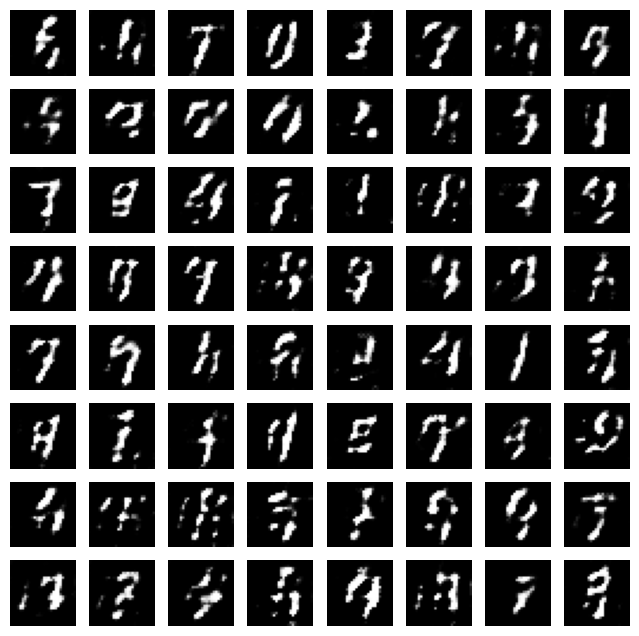

In [43]:
def generate_and_plot():
    noise = tf.random.normal([64, 100])
    predictions = generator(noise, training=False)

    plt.figure(figsize=(8, 8))
    for i in range(predictions.shape[0]):
        plt.subplot(8, 8, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
    plt.show()

generate_and_plot()